<a href="https://colab.research.google.com/github/hwasun-zip/EatsSpeed/blob/main/EatsSpeed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 머천트 카탈로그 요청 처리 프로세스 병목 분석 & SLA 자동 모니터링

# > ⚠️ 실제 쿠팡이츠 서비스/내부 데이터와 무관한 개인 학습 프로젝트입니다.
# > 공개 CS 티켓 데이터의 시간 분포를 참고해 카탈로그 운영 도메인 로직을 합성 반영했습니다.

In [2]:
# 임포트 & 시드 고정
import numpy as np
import pandas as pd
import sqlite3
from datetime import datetime, timedelta

RNG = np.random.default_rng(42)

In [5]:
# 요청 유형별 특성 정의 -> '5가지 요청 유형이 각각 어떤 성격을 가지는지'를 숫자로 미리 정의해두는 설정값 모음
REQUEST_TYPES = {
    "영업시간_휴무일_변경": {
        "lead_time_hours_mean": 2.0, "lead_time_hours_sigma": 0.5,
        "rework_prob": 0.10, "base_sla_hours": 24, "weekend_sla_hours": 2,
        "reject_reasons": ["운영시간 증빙 서류 미비", "기존 예약 건과 충돌"],
    },
    "가격_수정": {
        "lead_time_hours_mean": 2.3, "lead_time_hours_sigma": 0.5,
        "rework_prob": 0.35, "base_sla_hours": 12, "weekend_sla_hours": None,
        "reject_reasons": ["메뉴판 표기가와 불일치", "원부자재 원가 미반영", "부가세 표기 오류"],
    },
    "이미지_교체": {
        "lead_time_hours_mean": 3.4, "lead_time_hours_sigma": 0.6,
        "rework_prob": 0.18, "base_sla_hours": 48, "weekend_sla_hours": None,
        "reject_reasons": ["이미지 해상도 기준 미달", "워터마크/텍스트 삽입 이미지", "음식과 무관한 이미지"],
    },
    "신규_메뉴_등록": {
        "lead_time_hours_mean": 2.6, "lead_time_hours_sigma": 0.5,
        "rework_prob": 0.20, "base_sla_hours": 24, "weekend_sla_hours": None,
        "reject_reasons": ["필수 알레르기 정보 누락", "카테고리 분류 오류", "가격 정보 누락"],
    },
    "메뉴_설명_수정": {
        "lead_time_hours_mean": 1.6, "lead_time_hours_sigma": 0.4,
        "rework_prob": 0.08, "base_sla_hours": 24, "weekend_sla_hours": None,
        "reject_reasons": ["과장/허위 표현 포함", "글자수 제한 초과"],
    },
}

STORE_CATEGORIES = ["한식", "카페.디저트", "치킨", "중식", "분식", "일식", "피자.양식", "야식"]
N_TICKETS, N_MERCHANTS, N_REVIEWERS = 6000, 900, 12
START_DATE, END_DATE = datetime(2026, 1, 1), datetime(2026, 6, 30)

# 검수 난이도에 대한 합리적 가정(이미지=시각적 품질 검수 필요, 가격=원가 대사 확인 필요)을 바탕으로 상대적 크기 관계를 설계
# 절대적 수치보다 유형 간 상대적 격차와 그로 인한 병목 패턴에 분석의 초점이 있음

In [6]:
# 생성 함수 + 실행 (6000개의 요청 데이터를 하나씩 만들어내는 부분)
def random_timestamp(start, end):
    total_seconds = int((end - start).total_seconds())
    ts = start + timedelta(seconds=int(RNG.integers(0, total_seconds)))
    if RNG.random() < 0.35:
        ts = ts.replace(hour=int(RNG.integers(18, 23)), minute=int(RNG.integers(0, 60)))
    return ts

def generate_tickets(n=N_TICKETS):
    rows = []
    reviewer_skill = {f"reviewer_{i:02d}": RNG.uniform(0.8, 1.3) for i in range(1, N_REVIEWERS + 1)}

    for ticket_id in range(1, n + 1):
        req_type = RNG.choice(list(REQUEST_TYPES.keys()))
        cfg = REQUEST_TYPES[req_type]
        merchant_id = f"M{RNG.integers(1, N_MERCHANTS + 1):04d}"
        store_category = RNG.choice(STORE_CATEGORIES)
        reviewer_id = RNG.choice(list(reviewer_skill.keys()))
        skill_factor = reviewer_skill[reviewer_id]

        submitted_at = random_timestamp(START_DATE, END_DATE)
        assigned_at = submitted_at + timedelta(minutes=float(RNG.gamma(2.0, 15.0)))

        raw_lead_hours = RNG.lognormal(cfg["lead_time_hours_mean"], cfg["lead_time_hours_sigma"])
        lead_hours = raw_lead_hours * skill_factor
        review_completed_at = assigned_at + timedelta(hours=float(lead_hours))

        rework_count, reject_reason = 0, None
        cur_time = review_completed_at
        while RNG.random() < cfg["rework_prob"] * skill_factor and rework_count < 4:
            rework_count += 1
            reject_reason = RNG.choice(cfg["reject_reasons"])
            rework_wait = RNG.lognormal(1.8, 0.6)
            reverify = RNG.lognormal(cfg["lead_time_hours_mean"] * 0.6, 0.4)
            cur_time += timedelta(hours=float(rework_wait + reverify))

        review_result = "반려후승인" if rework_count > 0 else "승인"
        final_completed_at = cur_time if rework_count > 0 else review_completed_at
        reflected_at = final_completed_at + timedelta(hours=float(RNG.lognormal(0.4, 0.5)))

        day_of_week = submitted_at.strftime("%a")
        is_weekend = day_of_week in ["Fri", "Sat", "Sun"]
        sla_hours = cfg["weekend_sla_hours"] if (cfg["weekend_sla_hours"] and is_weekend) else cfg["base_sla_hours"]

        total_hours = (reflected_at - submitted_at).total_seconds() / 3600
        rows.append({
            "ticket_id": ticket_id, "merchant_id": merchant_id, "store_category": store_category,
            "request_type": req_type, "reviewer_id": reviewer_id,
            "submitted_at": submitted_at, "assigned_at": assigned_at,
            "review_completed_at": review_completed_at, "final_completed_at": final_completed_at,
            "reflected_at": reflected_at, "day_of_week": day_of_week,
            "review_result": review_result, "rework_count": rework_count, "reject_reason": reject_reason,
            "sla_hours": sla_hours, "total_processing_hours": round(total_hours, 2),
            "sla_breached": int(total_hours > sla_hours),
        })
    return pd.DataFrame(rows).sort_values("submitted_at").reset_index(drop=True)

tickets_df = generate_tickets()
conn = sqlite3.connect("itsspeed.db")
tickets_df.to_sql("catalog_requests", conn, if_exists="replace", index=False)
tickets_df.to_csv("catalog_requests.csv", index=False)

print(f"총 {len(tickets_df)}건 생성 완료")
tickets_df.head()

총 6000건 생성 완료


,ticket_id,merchant_id,store_category,request_type,reviewer_id,submitted_at,assigned_at,review_completed_at,final_completed_at,reflected_at,day_of_week,review_result,rework_count,reject_reason,sla_hours,total_processing_hours,sla_breached
0,5998,M0189,분식,가격_수정,reviewer_07,2026-01-01 00:05:52,2026-01-01 00:17:52.279988,2026-01-01 20:13:25.118322,2026-01-01 20:13:25.118322,2026-01-01 21:22:29.396841,Thu,승인,0,None,12,21.28,1
1,3229,M0112,카페.디저트,가격_수정,reviewer_01,2026-01-01 04:24:47,2026-01-01 05:25:56.223460,2026-01-02 05:44:27.045026,2026-01-02 12:01:01.816260,2026-01-02 13:12:25.588023,Thu,반려후승인,1,원부자재 원가 미반영,12,32.79,1
2,3396,M0043,카페.디저트,신규_메뉴_등록,reviewer_03,2026-01-01 04:46:32,2026-01-01 05:27:30.243448,2026-01-02 16:58:01.364137,2026-01-02 16:58:01.364137,2026-01-02 18:47:27.216820,Thu,승인,0,None,24,38.02,1
3,1817,M0539,일식,메뉴_설명_수정,reviewer_04,2026-01-01 05:00:09,2026-01-01 05:22:21.299630,2026-01-01 10:25:24.584942,2026-01-01 10:25:24.584942,2026-01-01 11:30:04.259436,Thu,승인,0,None,24,6.50,0
4,5669,M0212,중식,가격_수정,reviewer_11,2026-01-01 05:22:06,2026-01-01 06:08:56.651280,2026-01-01 13:23:04.663244,2026-01-01 13:23:04.663244,2026-01-01 13:59:36.941754,Thu,승인,0,None,12,8.63,0


In [8]:
# 1. 요청유형별 병목(TAT) 비교
# SQL 실행 (윈도우 함수로 중앙값까지)
query_1 = """
WITH ranked AS (
    SELECT
        request_type,
        total_processing_hours,
        NTILE(2) OVER (PARTITION BY request_type ORDER BY total_processing_hours) AS half
    FROM catalog_requests
)
SELECT
    request_type AS 요청유형,
    COUNT(*) AS 건수,
    ROUND(AVG(total_processing_hours), 1) AS 평균처리시간_h,
    ROUND(MAX(CASE WHEN half = 1 THEN total_processing_hours END), 1) AS 중앙값_근사_h
FROM ranked
GROUP BY request_type
ORDER BY 평균처리시간_h DESC;
"""
df_tat = pd.read_sql(query_1, conn)
df_tat

# 요청유형별로 "평균 얼마나 걸리는지" + "중앙값은 얼마인지"를 보고 싶었음

,요청유형,건수,평균처리시간_h,중앙값_근사_h
0,이미지_교체,1189,44.0,37.0
1,신규_메뉴_등록,1204,22.8,19.8
2,가격_수정,1184,21.3,17.8
3,영업시간_휴무일_변경,1219,12.5,10.8
4,메뉴_설명_수정,1204,9.1,8.0


In [9]:
# 2. SLA 위반율 (요일 가중 포함)
query_2 = """
SELECT
    request_type AS 요청유형,
    CASE WHEN day_of_week IN ('Fri','Sat','Sun') THEN '주말접수' ELSE '평일접수' END AS 접수구분,
    COUNT(*) AS 건수,
    ROUND(AVG(sla_hours), 1) AS 적용SLA_h,
    ROUND(AVG(sla_breached) * 100, 1) AS SLA위반율_pct
FROM catalog_requests
GROUP BY request_type, 접수구분
ORDER BY 요청유형, 접수구분;
"""
df_sla = pd.read_sql(query_2, conn)
df_sla

# 우리가 정한 목표(SLA)를 지켰나 못 지켰나를 보기 위함

,요청유형,접수구분,건수,적용SLA_h,SLA위반율_pct
0,가격_수정,주말접수,529,12.0,75.0
1,가격_수정,평일접수,655,12.0,71.3
2,메뉴_설명_수정,주말접수,552,24.0,1.8
3,메뉴_설명_수정,평일접수,652,24.0,1.5
4,신규_메뉴_등록,주말접수,555,24.0,37.7
5,신규_메뉴_등록,평일접수,649,24.0,32.8
6,영업시간_휴무일_변경,주말접수,498,2.0,100.0
7,영업시간_휴무일_변경,평일접수,721,24.0,5.8
8,이미지_교체,주말접수,516,48.0,32.4
9,이미지_교체,평일접수,673,48.0,32.8


In [10]:
# 3. 재반려(핑퐁) 지표 — 상점-운영팀 소통 실패 구간
query_3 = """
SELECT
    request_type AS 요청유형,
    COUNT(*) AS 전체건수,
    SUM(CASE WHEN rework_count >= 2 THEN 1 ELSE 0 END) AS 핑퐁건수,
    ROUND(100.0 * SUM(CASE WHEN rework_count >= 2 THEN 1 ELSE 0 END) / COUNT(*), 1) AS 핑퐁비율_pct,
    ROUND(AVG(CASE WHEN rework_count >= 2 THEN total_processing_hours END), 1) AS 핑퐁건_평균처리시간_h,
    ROUND(AVG(CASE WHEN rework_count < 2 THEN total_processing_hours END), 1) AS 일반건_평균처리시간_h
FROM catalog_requests
GROUP BY request_type
ORDER BY 핑퐁비율_pct DESC;
"""
df_pingpong = pd.read_sql(query_3, conn)
df_pingpong

# 왜 오래 걸렸는지의 원인 중 하나 -> 반려가 반복되면서(핑퐁) 시간이 늘어난 케이스가 얼마나 되는지

,요청유형,전체건수,핑퐁건수,핑퐁비율_pct,핑퐁건_평균처리시간_h,일반건_평균처리시간_h
0,가격_수정,1184,154,13.0,43.2,18.1
1,신규_메뉴_등록,1204,62,5.1,47.1,21.5
2,이미지_교체,1189,33,2.8,76.7,43.1
3,메뉴_설명_수정,1204,14,1.2,26.7,8.9
4,영업시간_휴무일_변경,1219,13,1.1,40.0,12.2


In [11]:
# 4. 담당자별 처리량/반려율
query_4 = """
SELECT
    reviewer_id AS 담당자,
    COUNT(*) AS 처리건수,
    ROUND(AVG(total_processing_hours), 1) AS 평균처리시간_h,
    ROUND(100.0 * SUM(CASE WHEN rework_count > 0 THEN 1 ELSE 0 END) / COUNT(*), 1) AS 반려율_pct,
    ROUND(100.0 * SUM(sla_breached) / COUNT(*), 1) AS SLA위반율_pct
FROM catalog_requests
GROUP BY reviewer_id
ORDER BY 반려율_pct DESC;
"""
df_reviewer = pd.read_sql(query_4, conn)
df_reviewer

# 사람 문제 아님 → 구조적 문제로 결론 강화

,담당자,처리건수,평균처리시간_h,반려율_pct,SLA위반율_pct
0,reviewer_07,518,23.2,23.9,41.1
1,reviewer_01,524,24.5,22.1,45.4
2,reviewer_06,472,24.1,21.6,43.2
3,reviewer_12,496,26.0,21.4,43.3
4,reviewer_03,503,24.7,20.7,40.6
5,reviewer_04,488,21.7,20.3,34.8
6,reviewer_08,503,22.3,18.7,41.9
7,reviewer_11,506,19.5,18.2,31.8
8,reviewer_02,495,20.4,17.6,37.0
9,reviewer_10,487,20.7,17.0,31.8


In [18]:
# 5. 자동화 — SLA 모니터링 + 주간 리포트 자동 생성
# 매주 월요일, 지난 1주일치 티켓을 SQL로 집계 → 미리 정한 규칙(rule)에 걸리면 자동으로 액션 아이템 문장을 생성 → 리포트로 출력

def generate_action_items(week_df: pd.DataFrame) -> list:
    """규칙 기반(Rule-based)으로 이번 주 데이터를 진단해 액션 아이템 문장을 생성"""
    items = []

    # 규칙 1: 요청유형 평균 TAT가 임계값(30h) 초과 -> 검수 병목
    tat_by_type = week_df.groupby('request_type')['total_processing_hours'].mean()
    for req_type, tat in tat_by_type.items():
        if tat > 30:
            items.append(
                f"[검토 권장] '{req_type}' 평균 처리시간 {tat:.1f}h로 임계치(30h) 초과 "
                f"→ 검수 프로세스 병목 가능성, 자동 검수 도구/체크리스트 도입 검토 권장"
            )

    # 규칙 2: 요청유형별 SLA 위반율 50% 초과
    sla_by_type = week_df.groupby('request_type')['sla_breached'].mean() * 100
    for req_type, rate in sla_by_type.items():
        if rate > 50:
            items.append(
                f"[검토 권장] '{req_type}' SLA 위반율 {rate:.1f}%로 과반 초과 "
                f"→ SLA 기준 적정성 재검토 또는 처리 우선순위 조정 필요"
            )

    # 규칙 2-1: 주말 SLA 위반율이 90% 이상 (정책-현실 괴리 탐지)
    weekend_df = week_df[week_df['day_of_week'].isin(['Fri', 'Sat', 'Sun'])]
    if len(weekend_df) > 0:
        weekend_sla_by_type = weekend_df.groupby('request_type')['sla_breached'].mean() * 100
        for req_type, rate in weekend_sla_by_type.items():
            if rate >= 90:
                items.append(
                    f"[정책 재검토 필요] '{req_type}' 주말 접수 SLA 위반율 {rate:.1f}% "
                    f"→ 현재 프로세스 구조상 SLA 기준 자체가 달성 불가능한 수준일 가능성, "
                    f"SLA 재설정 또는 주말 전담 패스트트랙 도입 검토"
                )

    # 규칙 3: 핑퐁(rework_count>=2) 비율 10% 초과
    pingpong_by_type = week_df.groupby('request_type').apply(
        lambda g: (g['rework_count'] >= 2).mean() * 100, include_groups=False
    )
    for req_type, rate in pingpong_by_type.items():
        if rate > 10:
            items.append(
                f"[검토 권장] '{req_type}' 재반려(핑퐁) 비율 {rate:.1f}% "
                f"→ 접수 단계에서 필수 첨부 서류/조건 명확화로 초기 반려율 감소 필요"
            )

    # 규칙 4: 담당자 반려율이 팀 평균 대비 1.2배 초과
    team_avg_reject = (week_df['rework_count'] > 0).mean()
    reject_by_reviewer = week_df.groupby('reviewer_id').apply(
        lambda g: (g['rework_count'] > 0).mean(), include_groups=False)
    for reviewer, rate in reject_by_reviewer.items():
        if team_avg_reject > 0 and rate > team_avg_reject * 1.2:
            items.append(
                f"[모니터링] '{reviewer}' 반려율 {rate*100:.1f}%로 팀 평균({team_avg_reject*100:.1f}%) 대비 높음 "
                f"→ 업무 배정/가이드 재점검 권장 (단, 표본 수 확인 필요)"
            )

    if not items:
        items.append("[정상] 이번 주 임계치를 초과한 항목 없음")

    return items

In [19]:
# 주간 리포트 생성 함수
def generate_weekly_report(df: pd.DataFrame, week_start: str) -> str:
    """지정한 주 시작일(월요일) 기준 1주일치 리포트 생성"""
    start = pd.Timestamp(week_start)
    end = start + timedelta(days=7)
    week_df = df[(df['submitted_at'] >= start) & (df['submitted_at'] < end)]

    if len(week_df) == 0:
        return f"# {week_start} 주간 리포트\n\n해당 주 데이터 없음"

    lines = []
    lines.append(f"# 카탈로그 운영 주간 리포트 ({start.date()} ~ {(end - timedelta(days=1)).date()})")
    lines.append("")
    lines.append(f"- 총 접수 건수: {len(week_df)}건")
    lines.append(f"- 전체 SLA 위반율: {week_df['sla_breached'].mean()*100:.1f}%")
    lines.append(f"- 전체 반려율: {(week_df['rework_count']>0).mean()*100:.1f}%")
    lines.append("")
    lines.append("## 요청유형별 요약")
    summary = week_df.groupby('request_type').agg(
        건수=('ticket_id', 'count'),
        평균처리시간_h=('total_processing_hours', 'mean'),
        SLA위반율_pct=('sla_breached', lambda x: x.mean()*100),
    ).round(1)
    lines.append(summary.to_markdown())
    lines.append("")
    lines.append("## 자동 진단 액션 아이템")
    for item in generate_action_items(week_df):
        lines.append(f"- {item}")

    return "\n".join(lines)

In [20]:
# 실행 (실제 한 주 골라서 리포트 생성)
from datetime import timedelta

# DB에서 다시 불러오면서 submitted_at을 datetime으로 명확히 변환
df = pd.read_sql("SELECT * FROM catalog_requests", conn, parse_dates=['submitted_at'])

report = generate_weekly_report(df, "2026-03-09")
print(report)

# 카탈로그 운영 주간 리포트 (2026-03-09 ~ 2026-03-15)

- 총 접수 건수: 218건
- 전체 SLA 위반율: 42.2%
- 전체 반려율: 18.8%

## 요청유형별 요약
| request_type         |   건수 |   평균처리시간_h |   SLA위반율_pct |
|:---------------------|-------:|-----------------:|----------------:|
| 가격_수정            |     47 |             21   |            78.7 |
| 메뉴_설명_수정       |     37 |             10.4 |             2.7 |
| 신규_메뉴_등록       |     50 |             22.3 |            40   |
| 영업시간_휴무일_변경 |     40 |             13.6 |            57.5 |
| 이미지_교체          |     44 |             50.5 |            25   |

## 자동 진단 액션 아이템
- [검토 권장] '이미지_교체' 평균 처리시간 50.5h로 임계치(30h) 초과 → 검수 프로세스 병목 가능성, 자동 검수 도구/체크리스트 도입 검토 권장
- [검토 권장] '가격_수정' SLA 위반율 78.7%로 과반 초과 → SLA 기준 적정성 재검토 또는 처리 우선순위 조정 필요
- [검토 권장] '영업시간_휴무일_변경' SLA 위반율 57.5%로 과반 초과 → SLA 기준 적정성 재검토 또는 처리 우선순위 조정 필요
- [정책 재검토 필요] '영업시간_휴무일_변경' 주말 접수 SLA 위반율 100.0% → 현재 프로세스 구조상 SLA 기준 자체가 달성 불가능한 수준일 가능성, SLA 재설정 또는 주말 전담 패스트트랙 도입 검토
- [검토 권장] '가격_수정' 재반려(핑퐁) 비율 10.6% → 접수 단계에서 필수 첨부 서류/조건 명

In [21]:
## 6. 스케줄링 (매주 자동 실행 시연)

# > 코랩 노트북은 브라우저를 계속 열어둬야 하므로 실제 장기 스케줄링에는 적합하지 않습니다.
# > 아래는 스케줄링 '로직 자체'를 시연하는 코드이며, 실제 운영 환경에서는 로컬 서버/사내 배치 서버에 스크립트로 배포하고 cron으로 등록하는 것을 가정합니다.

In [23]:
# schedule 라이브러리 설치 & 로직 시연
!pip install schedule -q

import schedule
import time

def run_weekly_job(reference_date=None):
    """매주 월요일 실행될 작업: 지난 1주일 리포트 생성
    reference_date: 데모용 - 실제 운영에서는 항상 오늘 날짜를 씀
    """
    today = pd.Timestamp(reference_date) if reference_date else pd.Timestamp.today().normalize()
    last_monday = today - pd.Timedelta(days=today.weekday() + 7)  # 지난주 월요일
    report = generate_weekly_report(df, str(last_monday.date()))
    print(report)
    with open(f"weekly_report_{last_monday.date()}.md", "w", encoding="utf-8") as f:
        f.write(report)

# 시연용: 데이터의 마지막 날짜를 '오늘'이라고 가정하고 실행
demo_today = df['submitted_at'].max()
run_weekly_job(reference_date=demo_today)

# reference_date 없이 호출 -> 자동으로 오늘 날짜 사용
# schedule.every().monday.at("09:00").do(run_weekly_job)

print("\n[스케줄 등록 완료] 실제 서버에서는 아래처럼 무한 대기 루프를 돌립니다:")
print("""
while True:
    schedule.run_pending()
    time.sleep(60)
""")

# 카탈로그 운영 주간 리포트 (2026-06-22 ~ 2026-06-28)

- 총 접수 건수: 261건
- 전체 SLA 위반율: 36.8%
- 전체 반려율: 18.0%

## 요청유형별 요약
| request_type         |   건수 |   평균처리시간_h |   SLA위반율_pct |
|:---------------------|-------:|-----------------:|----------------:|
| 가격_수정            |     51 |             23.1 |            68.6 |
| 메뉴_설명_수정       |     47 |              8.7 |             2.1 |
| 신규_메뉴_등록       |     54 |             19.4 |            25.9 |
| 영업시간_휴무일_변경 |     65 |             13.5 |            49.2 |
| 이미지_교체          |     44 |             43   |            31.8 |

## 자동 진단 액션 아이템
- [검토 권장] '이미지_교체' 평균 처리시간 43.0h로 임계치(30h) 초과 → 검수 프로세스 병목 가능성, 자동 검수 도구/체크리스트 도입 검토 권장
- [검토 권장] '가격_수정' SLA 위반율 68.6%로 과반 초과 → SLA 기준 적정성 재검토 또는 처리 우선순위 조정 필요
- [정책 재검토 필요] '영업시간_휴무일_변경' 주말 접수 SLA 위반율 100.0% → 현재 프로세스 구조상 SLA 기준 자체가 달성 불가능한 수준일 가능성, SLA 재설정 또는 주말 전담 패스트트랙 도입 검토
- [검토 권장] '가격_수정' 재반려(핑퐁) 비율 21.6% → 접수 단계에서 필수 첨부 서류/조건 명확화로 초기 반려율 감소 필요
- [모니터링] 'reviewer_04' 반려율 25.0%로 팀 평균(18.0%) 대비 높음 → 업무 배정/가이

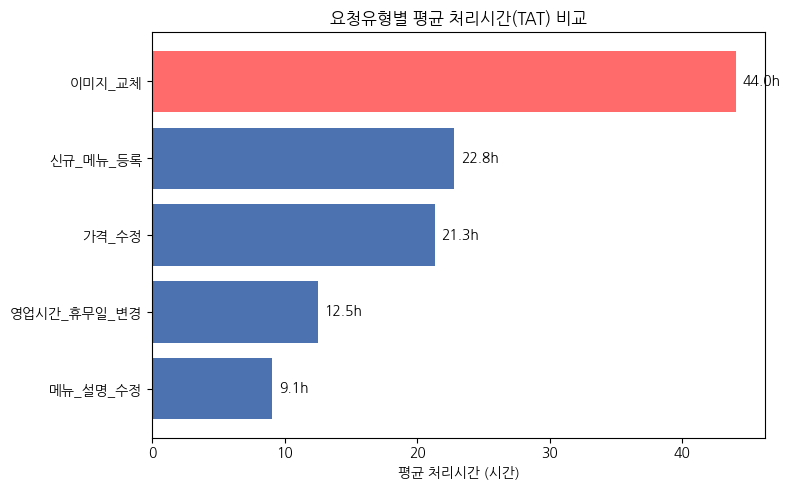

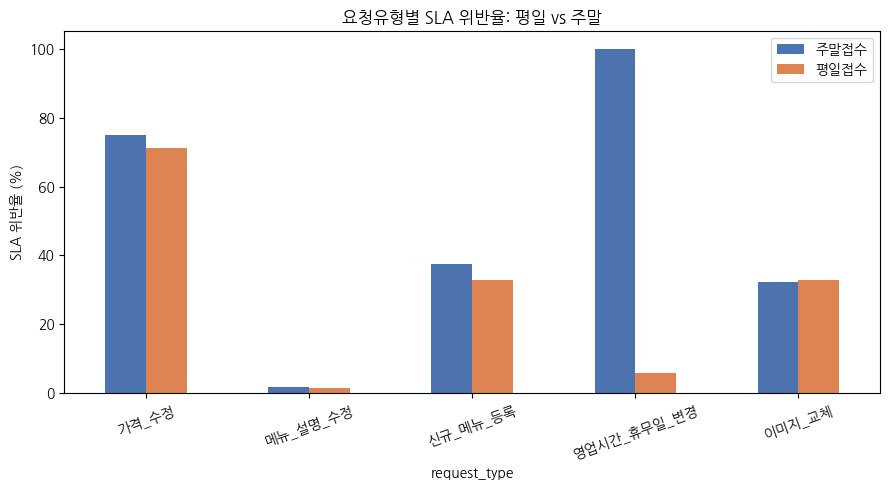

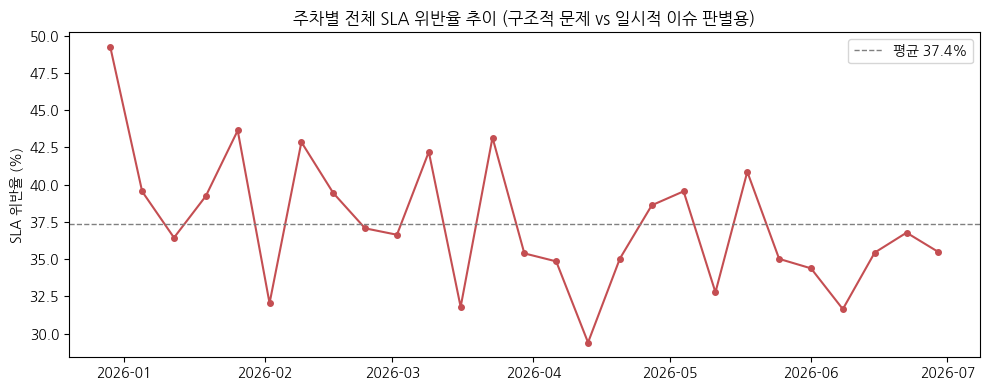

In [28]:
# 7. 시각화
# 한글 폰트 설치
!apt -qq -y install fonts-nanum > /dev/null

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

# 차트1: 요청유형별 평균 TAT
tat = df.groupby('request_type')['total_processing_hours'].mean().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#FF6B6B' if v == tat.max() else '#4C72B0' for v in tat.values]
ax.barh(tat.index, tat.values, color=colors)
ax.set_xlabel('평균 처리시간 (시간)')
ax.set_title('요청유형별 평균 처리시간(TAT) 비교')
for i, v in enumerate(tat.values):
    ax.text(v + 0.5, i, f'{v:.1f}h', va='center')
plt.tight_layout()
plt.show()

# 차트2: SLA 위반율 평일 vs 주말
df['접수구분'] = df['day_of_week'].isin(['Fri','Sat','Sun']).map({True:'주말접수', False:'평일접수'})
pivot = df.groupby(['request_type', '접수구분'])['sla_breached'].mean().unstack() * 100

fig, ax = plt.subplots(figsize=(9, 5))
pivot.plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452'])
ax.set_ylabel('SLA 위반율 (%)')
ax.set_title('요청유형별 SLA 위반율: 평일 vs 주말')
ax.set_xticklabels(pivot.index, rotation=20)
ax.legend(title='')
plt.tight_layout()
plt.show()

# 차트3: 주차별 SLA 위반율 추이
df['week'] = df['submitted_at'].dt.to_period('W').apply(lambda p: p.start_time)
weekly_sla = df.groupby('week')['sla_breached'].mean() * 100

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(weekly_sla.index, weekly_sla.values, marker='o', color='#C44E52', linewidth=1.5, markersize=4)
ax.axhline(weekly_sla.mean(), color='gray', linestyle='--', linewidth=1, label=f'평균 {weekly_sla.mean():.1f}%')
ax.set_ylabel('SLA 위반율 (%)')
ax.set_title('주차별 전체 SLA 위반율 추이 (구조적 문제 vs 일시적 이슈 판별용)')
ax.legend()
plt.tight_layout()
plt.show()